# Loan Approval Prediction Model

This notebook builds a machine learning model to predict loan approval based on applicant data and uploaded documents. Users can upload their information and get an instant approval prediction.

## 1. Import Required Libraries

In [16]:
# Generate 1000 synthetic loan samples
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 1000

# Define possible values
genders = ['Male', 'Female']
occupations = ['Engineer', 'Teacher', 'Manager', 'Accountant', 'Nurse', 'Lawyer', 'Doctor', 
               'Consultant', 'Analyst', 'IT', 'Designer', 'Sales', 'Marketing', 'Chef',
               'Architect', 'Pharmacist', 'Student', 'Writer', 'Banker', 'Researcher']
education_levels = ['High School', "Associate's", "Bachelor's", "Master's", 'Doctoral']
marital_statuses = ['Single', 'Married']

# Generate features
ages = np.random.randint(22, 60, n_samples)
genders_data = np.random.choice(genders, n_samples)
occupations_data = np.random.choice(occupations, n_samples)
education_data = np.random.choice(education_levels, n_samples, p=[0.15, 0.15, 0.40, 0.20, 0.10])
marital_data = np.random.choice(marital_statuses, n_samples, p=[0.4, 0.6])

# Generate income based on education and age (more realistic)
base_income = {
    'High School': 30000, "Associate's": 40000, "Bachelor's": 55000, 
    "Master's": 75000, 'Doctoral': 100000
}
incomes = []
for i in range(n_samples):
    base = base_income[education_data[i]]
    age_factor = (ages[i] - 22) * 1500  # Experience adds income
    noise = np.random.normal(0, 15000)
    income = max(20000, base + age_factor + noise)
    incomes.append(int(income))

# Generate credit scores based on income and age
credit_scores = []
for i in range(n_samples):
    base_score = 550 + (incomes[i] / 1000) * 1.5 + ages[i] * 1.5
    noise = np.random.normal(0, 40)
    score = min(850, max(300, int(base_score + noise)))
    credit_scores.append(score)

# Generate loan status based on realistic criteria
loan_statuses = []
for i in range(n_samples):
    # Calculate approval probability based on multiple factors
    score = 0
    
    # Credit score impact (most important)
    if credit_scores[i] >= 750: score += 40
    elif credit_scores[i] >= 700: score += 30
    elif credit_scores[i] >= 650: score += 15
    elif credit_scores[i] >= 600: score += 5
    else: score -= 10
    
    # Income impact
    if incomes[i] >= 100000: score += 25
    elif incomes[i] >= 70000: score += 20
    elif incomes[i] >= 50000: score += 10
    elif incomes[i] >= 35000: score += 5
    else: score -= 5
    
    # Education impact
    edu_scores = {'Doctoral': 10, "Master's": 8, "Bachelor's": 5, "Associate's": 3, 'High School': 0}
    score += edu_scores[education_data[i]]
    
    # Age impact (stability)
    if 30 <= ages[i] <= 50: score += 5
    
    # Marital status (slight impact)
    if marital_data[i] == 'Married': score += 3
    
    # Add randomness
    score += np.random.normal(0, 10)
    
    # Decision threshold with some overlap for uncertainty
    approval_prob = 1 / (1 + np.exp(-0.1 * (score - 50)))  # Sigmoid function
    loan_statuses.append('Approved' if np.random.random() < approval_prob else 'Denied')

# Create DataFrame
synthetic_df = pd.DataFrame({
    'age': ages,
    'gender': genders_data,
    'occupation': occupations_data,
    'education_level': education_data,
    'marital_status': marital_data,
    'income': incomes,
    'credit_score': credit_scores,
    'loan_status': loan_statuses
})

# Save to CSV
synthetic_df.to_csv('loan.csv', index=False)

print(f"✓ Generated {n_samples} synthetic samples!")
print(f"\nDataset Statistics:")
print(f"  Loan Status Distribution:")
print(synthetic_df['loan_status'].value_counts())
print(f"\n  Approval Rate: {(synthetic_df['loan_status'] == 'Approved').mean()*100:.1f}%")
print(f"\n  Income Range: ${synthetic_df['income'].min():,} - ${synthetic_df['income'].max():,}")
print(f"  Credit Score Range: {synthetic_df['credit_score'].min()} - {synthetic_df['credit_score'].max()}")
print(f"  Age Range: {synthetic_df['age'].min()} - {synthetic_df['age'].max()}")

✓ Generated 1000 synthetic samples!

Dataset Statistics:
  Loan Status Distribution:
loan_status
Approved    639
Denied      361
Name: count, dtype: int64

  Approval Rate: 63.9%

  Income Range: $20,000 - $166,744
  Credit Score Range: 521 - 850
  Age Range: 22 - 59


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load and Explore the Dataset

In [18]:
# Load the dataset
df = pd.read_csv('loan.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (1000, 8)

First 5 rows:
   age  gender  occupation education_level marital_status  income  \
0   50  Female  Accountant      Bachelor's        Married   83255   
1   36    Male     Teacher     Associate's         Single   81331   
2   29    Male   Architect        Master's        Married  103052   
3   42    Male     Teacher        Master's        Married  107014   
4   40    Male  Accountant     High School        Married   58193   

   credit_score loan_status  
0           669      Denied  
1           721    Approved  
2           724      Denied  
3           734    Approved  
4           694      Denied  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              1000 non-null   int64 
 1   gender           1000 non-null   object
 2   occupation       1000 non-null   object
 3   education_level

In [19]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Target variable distribution
print("\nLoan Status Distribution:")
print(df['loan_status'].value_counts())
print("\nLoan Status Percentage:")
print(df['loan_status'].value_counts(normalize=True) * 100)

Missing Values:
age                0
gender             0
occupation         0
education_level    0
marital_status     0
income             0
credit_score       0
loan_status        0
dtype: int64

Loan Status Distribution:
loan_status
Approved    639
Denied      361
Name: count, dtype: int64

Loan Status Percentage:
loan_status
Approved    63.9
Denied      36.1
Name: proportion, dtype: float64


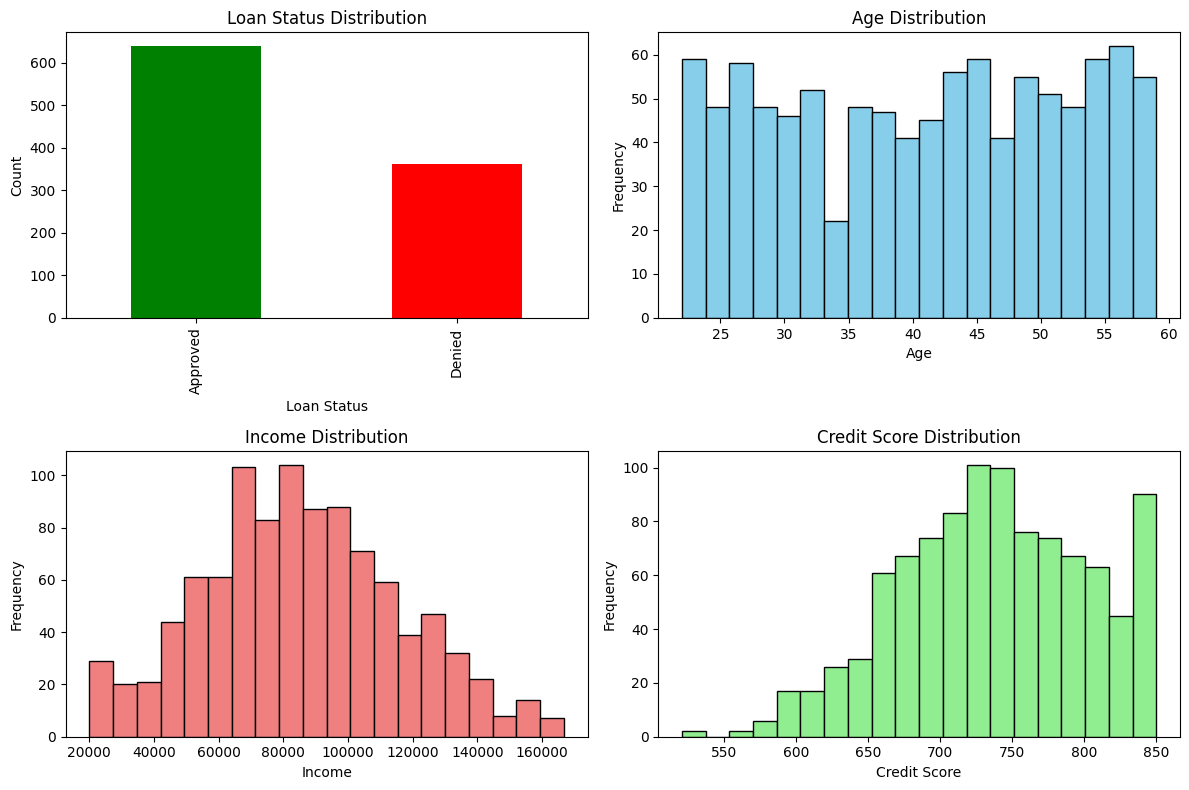

In [20]:
# Visualize the distribution
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loan Status Distribution
df['loan_status'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Loan Status Distribution')
axes[0, 0].set_xlabel('Loan Status')
axes[0, 0].set_ylabel('Count')

# Age distribution
axes[0, 1].hist(df['age'], bins=20, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Age Distribution')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')

# Income distribution
axes[1, 0].hist(df['income'], bins=20, color='lightcoral', edgecolor='black')
axes[1, 0].set_title('Income Distribution')
axes[1, 0].set_xlabel('Income')
axes[1, 0].set_ylabel('Frequency')

# Credit Score distribution
axes[1, 1].hist(df['credit_score'], bins=20, color='lightgreen', edgecolor='black')
axes[1, 1].set_title('Credit Score Distribution')
axes[1, 1].set_xlabel('Credit Score')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Data Preprocessing and Feature Engineering

In [21]:
# Create a copy for preprocessing
df_processed = df.copy()

# Encode categorical variables
label_encoders = {}
categorical_columns = ['gender', 'occupation', 'education_level', 'marital_status', 'loan_status']

for col in categorical_columns:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le

print("Encoded categorical variables:")
print(df_processed.head())
print("\nLabel Encoders:")
for col, le in label_encoders.items():
    print(f"{col}: {dict(enumerate(le.classes_))}")

Encoded categorical variables:
   age  gender  occupation  education_level  marital_status  income  \
0   50       0           0                1               0   83255   
1   36       1          18                0               1   81331   
2   29       1           2                4               0  103052   
3   42       1          18                4               0  107014   
4   40       1           0                3               0   58193   

   credit_score  loan_status  
0           669            1  
1           721            0  
2           724            1  
3           734            0  
4           694            1  

Label Encoders:
gender: {0: 'Female', 1: 'Male'}
occupation: {0: 'Accountant', 1: 'Analyst', 2: 'Architect', 3: 'Banker', 4: 'Chef', 5: 'Consultant', 6: 'Designer', 7: 'Doctor', 8: 'Engineer', 9: 'IT', 10: 'Lawyer', 11: 'Manager', 12: 'Marketing', 13: 'Nurse', 14: 'Pharmacist', 15: 'Researcher', 16: 'Sales', 17: 'Student', 18: 'Teacher', 19: 'Writer'}
e

In [22]:
# Create additional features based on domain knowledge
# REMOVED redundant credit_income_ratio (it's mathematically similar to debt_to_income_ratio)
df_processed['debt_to_income_ratio'] = (df_processed['credit_score'] * 100) / df_processed['income']
df_processed['age_income_interaction'] = df_processed['age'] * df_processed['income'] / 1000

# Normalize numeric features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_columns = ['age', 'income', 'credit_score', 'debt_to_income_ratio', 'age_income_interaction']
df_processed[numeric_columns] = scaler.fit_transform(df_processed[numeric_columns])

print("Features after engineering and normalization (removed redundant credit_income_ratio):")
print(df_processed.head())
print("\nShape:", df_processed.shape)

Features after engineering and normalization (removed redundant credit_income_ratio):
        age  gender  occupation  education_level  marital_status    income  \
0  0.811544       0           0                1               0 -0.075475   
1 -0.443467       1          18                0               1 -0.138780   
2 -1.070973       1           2                4               0  0.575904   
3  0.094395       1          18                4               0  0.706266   
4 -0.084893       1           0                3               0 -0.900088   

   credit_score  loan_status  debt_to_income_ratio  age_income_interaction  
0     -1.033514            1             -0.419632                0.238184  
1     -0.246870            0             -0.236432               -0.390159  
2     -0.201487            1             -0.642703               -0.359327  
3     -0.050209            0             -0.679513                0.407039  
4     -0.655320            1              0.439607          

## 4. Split Data into Train and Test Sets

In [23]:
# Separate features and target
X = df_processed.drop('loan_status', axis=1)
y = df_processed['loan_status']

# Apply SMOTE to balance the classes
print("Before SMOTE:")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print(f"Class distribution: {dict(zip(*np.unique(y_balanced, return_counts=True)))}")
print(f"\nTotal samples after SMOTE: {len(X_balanced)}")

# Split the balanced data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Total features: {X_train.shape[1]}")

Before SMOTE:
Class distribution: {np.int64(0): np.int64(639), np.int64(1): np.int64(361)}

After SMOTE:
Class distribution: {np.int64(0): np.int64(639), np.int64(1): np.int64(639)}

Total samples after SMOTE: 1278

Training set size: 1022
Testing set size: 256
Total features: 9


## 5. Train Classification Model

In [24]:
# ============================================================
# STEP 1: Start with Logistic Regression (simpler baseline model)
# ============================================================
print("=" * 60)
print("MODEL 1: LOGISTIC REGRESSION (Baseline with Regularization)")
print("=" * 60)

# Logistic Regression with L2 regularization (C=1.0 is default, lower = more regularization)
log_reg = LogisticRegression(C=0.5, penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)

# Cross-validation with 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation scores
cv_scores_lr = cross_val_score(log_reg, X_balanced, y_balanced, cv=cv, scoring='accuracy')
cv_f1_lr = cross_val_score(log_reg, X_balanced, y_balanced, cv=cv, scoring='f1')

print(f"\nCross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std() * 2:.4f})")
print(f"  F1-Score: {cv_f1_lr.mean():.4f} (+/- {cv_f1_lr.std() * 2:.4f})")

# Fit on training set for final evaluation
log_reg.fit(X_train, y_train)
print(f"\n✓ Logistic Regression trained successfully!")

MODEL 1: LOGISTIC REGRESSION (Baseline with Regularization)

Cross-Validation Results (5-Fold):
  Accuracy: 0.7707 (+/- 0.0476)
  F1-Score: 0.7695 (+/- 0.0462)

✓ Logistic Regression trained successfully!


MODEL 2: RANDOM FOREST (Reduced Complexity)

Cross-Validation Results (5-Fold):
  Accuracy: 0.7817 (+/- 0.0485)
  F1-Score: 0.7748 (+/- 0.0475)

✓ Random Forest trained successfully!

Top Features by Importance:
                  Feature  Importance
6            credit_score    0.362562
5                  income    0.204147
7    debt_to_income_ratio    0.165196
8  age_income_interaction    0.139119
0                     age    0.064309
2              occupation    0.035542
3         education_level    0.020735
4          marital_status    0.004519
1                  gender    0.003871


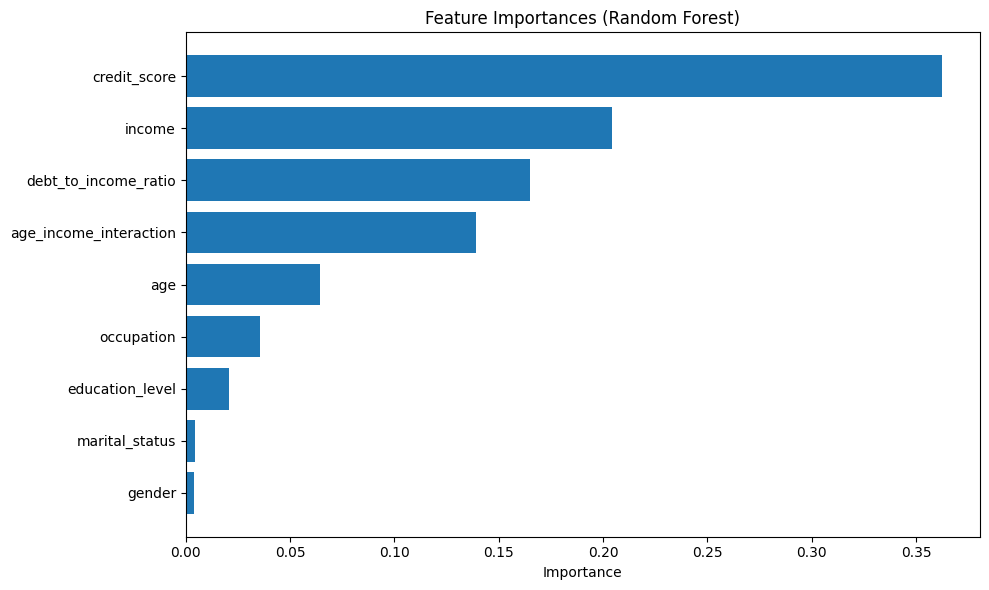

In [25]:
# ============================================================
# STEP 2: Random Forest with Reduced Complexity
# ============================================================
print("=" * 60)
print("MODEL 2: RANDOM FOREST (Reduced Complexity)")
print("=" * 60)

# Random Forest with reduced complexity to avoid overfitting
# - Fewer trees (50 instead of 100)
# - Shallower depth (5 instead of 10)
# - min_samples_split and min_samples_leaf to prevent overfitting
model = RandomForestClassifier(
    n_estimators=50, 
    max_depth=5, 
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42, 
    n_jobs=-1
)

# Cross-validation scores
cv_scores_rf = cross_val_score(model, X_balanced, y_balanced, cv=cv, scoring='accuracy')
cv_f1_rf = cross_val_score(model, X_balanced, y_balanced, cv=cv, scoring='f1')

print(f"\nCross-Validation Results (5-Fold):")
print(f"  Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std() * 2:.4f})")
print(f"  F1-Score: {cv_f1_rf.mean():.4f} (+/- {cv_f1_rf.std() * 2:.4f})")

# Fit on training set
model.fit(X_train, y_train)
print(f"\n✓ Random Forest trained successfully!")

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop Features by Importance:")
print(feature_importance)

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Evaluate Model Performance

MODEL COMPARISON: Cross-Validation Results

                   Model  CV Accuracy  CV Accuracy Std  CV F1-Score  CV F1-Score Std
Logistic Regression (L2)     0.770748         0.023789     0.769485         0.023109
 Random Forest (Reduced)     0.781703         0.024266     0.774811         0.023764

TEST SET PERFORMANCE

Logistic Regression:
  Test Accuracy:  0.7734
  Test Precision: 0.7917
  Test Recall:    0.7422
  Test F1-Score:  0.7661

Random Forest:
  Test Accuracy:  0.7930
  Test Precision: 0.8261
  Test Recall:    0.7422
  Test F1-Score:  0.7819


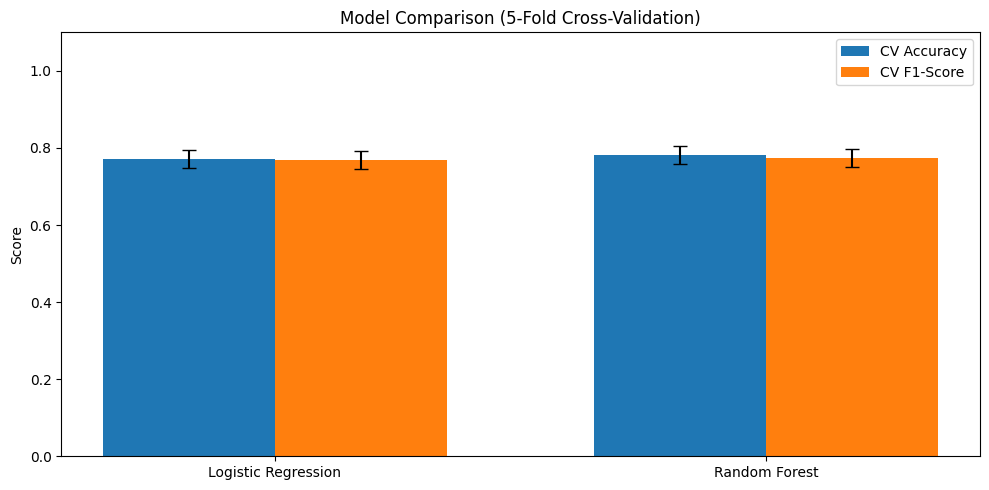

In [26]:
# ============================================================
# MODEL COMPARISON AND EVALUATION
# ============================================================
print("=" * 60)
print("MODEL COMPARISON: Cross-Validation Results")
print("=" * 60)

# Compare models
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (L2)', 'Random Forest (Reduced)'],
    'CV Accuracy': [cv_scores_lr.mean(), cv_scores_rf.mean()],
    'CV Accuracy Std': [cv_scores_lr.std(), cv_scores_rf.std()],
    'CV F1-Score': [cv_f1_lr.mean(), cv_f1_rf.mean()],
    'CV F1-Score Std': [cv_f1_lr.std(), cv_f1_rf.std()]
})

print("\n" + comparison_df.to_string(index=False))

# Predictions on test set for both models
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = model.predict(X_test)

# Calculate test metrics
print("\n" + "=" * 60)
print("TEST SET PERFORMANCE")
print("=" * 60)

print("\nLogistic Regression:")
print(f"  Test Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Test Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Test Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")

print("\nRandom Forest:")
print(f"  Test Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Test Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Test Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"  Test F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

# Visualize comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(2)
width = 0.35

bars1 = ax.bar(x - width/2, [cv_scores_lr.mean(), cv_scores_rf.mean()], width, 
               label='CV Accuracy', yerr=[cv_scores_lr.std(), cv_scores_rf.std()], capsize=5)
bars2 = ax.bar(x + width/2, [cv_f1_lr.mean(), cv_f1_rf.mean()], width, 
               label='CV F1-Score', yerr=[cv_f1_lr.std(), cv_f1_rf.std()], capsize=5)

ax.set_ylabel('Score')
ax.set_title('Model Comparison (5-Fold Cross-Validation)')
ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'Random Forest'])
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

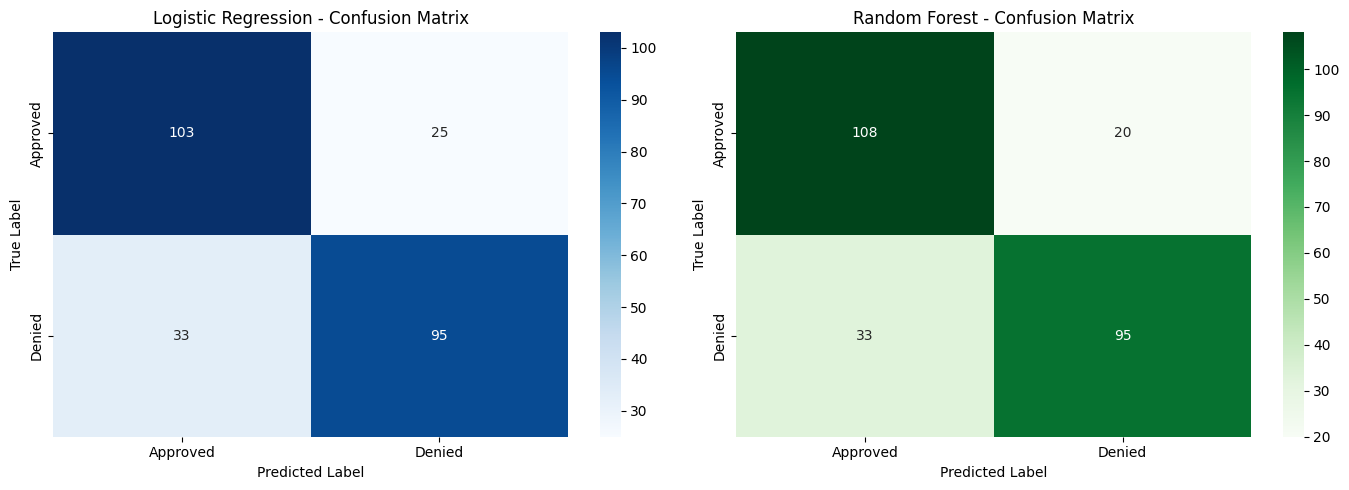


Detailed Classification Reports:

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Approved       0.76      0.80      0.78       128
      Denied       0.79      0.74      0.77       128

    accuracy                           0.77       256
   macro avg       0.77      0.77      0.77       256
weighted avg       0.77      0.77      0.77       256


RANDOM FOREST
              precision    recall  f1-score   support

    Approved       0.77      0.84      0.80       128
      Denied       0.83      0.74      0.78       128

    accuracy                           0.79       256
   macro avg       0.80      0.79      0.79       256
weighted avg       0.80      0.79      0.79       256



In [27]:
# Confusion Matrices for both models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['Approved', 'Denied'])
axes[0].set_yticklabels(['Approved', 'Denied'])

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['Approved', 'Denied'])
axes[1].set_yticklabels(['Approved', 'Denied'])

plt.tight_layout()
plt.show()

print("\nDetailed Classification Reports:")
print("\n" + "=" * 40)
print("LOGISTIC REGRESSION")
print("=" * 40)
print(classification_report(y_test, y_pred_lr, target_names=['Approved', 'Denied']))

print("\n" + "=" * 40)
print("RANDOM FOREST")
print("=" * 40)
print(classification_report(y_test, y_pred_rf, target_names=['Approved', 'Denied']))

## 7. Create Prediction Function for User Input

In [28]:
# Select the best model based on cross-validation results
# Using Logistic Regression as it's more interpretable and less prone to overfitting
best_model = log_reg if cv_f1_lr.mean() >= cv_f1_rf.mean() else model
best_model_name = "Logistic Regression" if cv_f1_lr.mean() >= cv_f1_rf.mean() else "Random Forest"

print(f"✓ Selected best model: {best_model_name}")

def predict_loan_approval(age, gender, occupation, education_level, marital_status, income, credit_score):
    """
    Predict loan approval status based on user input
    
    Parameters:
    - age: int
    - gender: str ('Male' or 'Female')
    - occupation: str
    - education_level: str ('High School', 'Associate's', 'Bachelor's', 'Master's', 'Doctoral')
    - marital_status: str ('Single' or 'Married')
    - income: float
    - credit_score: int
    
    Returns:
    - Dictionary with prediction and confidence
    """
    
    # Create input dataframe
    input_data = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'occupation': [occupation],
        'education_level': [education_level],
        'marital_status': [marital_status],
        'income': [income],
        'credit_score': [credit_score]
    })
    
    # Encode categorical variables
    for col in ['gender', 'occupation', 'education_level', 'marital_status']:
        input_data[col] = label_encoders[col].transform(input_data[col])
    
    # Create features (removed credit_income_ratio)
    input_data['debt_to_income_ratio'] = (input_data['credit_score'] * 100) / input_data['income']
    input_data['age_income_interaction'] = input_data['age'] * input_data['income'] / 1000
    
    # Normalize numeric features
    numeric_cols = ['age', 'income', 'credit_score', 'debt_to_income_ratio', 'age_income_interaction']
    input_data[numeric_cols] = scaler.transform(input_data[numeric_cols])
    
    # Select features in the same order as training
    input_data = input_data[X.columns]
    
    # Make prediction using best model
    prediction = best_model.predict(input_data)[0]
    probability = best_model.predict_proba(input_data)[0]
    
    # 0 = Approved (alphabetically first), 1 = Denied
    status = 'APPROVED' if prediction == 0 else 'DENIED'
    confidence = max(probability) * 100
    
    return {
        'status': status,
        'confidence': confidence,
        'approved_probability': probability[0] * 100,
        'denied_probability': probability[1] * 100
    }

print("✓ Prediction function created successfully!")

✓ Selected best model: Random Forest
✓ Prediction function created successfully!


## 8. Test Prediction with Sample User Data

In [29]:
# Test Case 1: High probability of approval
print("=" * 60)
print("TEST CASE 1: High Income, High Credit Score")
print("=" * 60)

result1 = predict_loan_approval(
    age=42,
    gender='Male',
    occupation='Manager',
    education_level="Master's",
    marital_status='Married',
    income=110000,
    credit_score=790
)

print(f"Status: {result1['status']}")
print(f"Confidence: {result1['confidence']:.2f}%")
print(f"Approved Probability: {result1['approved_probability']:.2f}%")
print(f"Denied Probability: {result1['denied_probability']:.2f}%")
print()

# Test Case 2: Low probability of approval
print("=" * 60)
print("TEST CASE 2: Low Income, Low Credit Score")
print("=" * 60)

result2 = predict_loan_approval(
    age=24,
    gender='Female',
    occupation='Student',
    education_level='High School',
    marital_status='Single',
    income=25000,
    credit_score=580
)

print(f"Status: {result2['status']}")
print(f"Confidence: {result2['confidence']:.2f}%")
print(f"Approved Probability: {result2['approved_probability']:.2f}%")
print(f"Denied Probability: {result2['denied_probability']:.2f}%")
print()

# Test Case 3: Medium probability
print("=" * 60)
print("TEST CASE 3: Medium Income, Medium Credit Score")
print("=" * 60)

result3 = predict_loan_approval(
    age=35,
    gender='Male',
    occupation='Engineer',
    education_level="Bachelor's",
    marital_status='Married',
    income=75000,
    credit_score=710
)

print(f"Status: {result3['status']}")
print(f"Confidence: {result3['confidence']:.2f}%")
print(f"Approved Probability: {result3['approved_probability']:.2f}%")
print(f"Denied Probability: {result3['denied_probability']:.2f}%")

TEST CASE 1: High Income, High Credit Score
Status: APPROVED
Confidence: 87.98%
Approved Probability: 87.98%
Denied Probability: 12.02%

TEST CASE 2: Low Income, Low Credit Score
Status: DENIED
Confidence: 96.54%
Approved Probability: 3.46%
Denied Probability: 96.54%

TEST CASE 3: Medium Income, Medium Credit Score
Status: DENIED
Confidence: 51.80%
Approved Probability: 48.20%
Denied Probability: 51.80%


## 9. Interactive Prediction Interface

Use the function below to make predictions with your own data. Simply modify the values and run the cell to get your loan approval prediction.

In [30]:
# Interactive user input section
print("=" * 60)
print("INTERACTIVE LOAN APPROVAL PREDICTION")
print("=" * 60)
print("\nModify the values below and run this cell to get your prediction:\n")

# User Input
age = 35  # Change this
gender = 'Male'  # 'Male' or 'Female'
occupation = 'Engineer'  # Any occupation
education_level = "Bachelor's"  # 'High School', 'Associate's', 'Bachelor's', 'Master's', 'Doctoral'
marital_status = 'Married'  # 'Single' or 'Married'
income = 85000  # Annual income
credit_score = 740  # Credit score (typically 300-850)

# Get prediction
result = predict_loan_approval(age, gender, occupation, education_level, marital_status, income, credit_score)

print("\n" + "=" * 60)
print("PREDICTION RESULT")
print("=" * 60)
print(f"\nYour Loan Application Status: {result['status']}")
print(f"Confidence Level: {result['confidence']:.2f}%")
print(f"\nDetailed Probabilities:")
print(f"  • Approved: {result['approved_probability']:.2f}%")
print(f"  • Denied:   {result['denied_probability']:.2f}%")
print("\n" + "=" * 60)

INTERACTIVE LOAN APPROVAL PREDICTION

Modify the values below and run this cell to get your prediction:


PREDICTION RESULT

Your Loan Application Status: APPROVED
Confidence Level: 62.81%

Detailed Probabilities:
  • Approved: 62.81%
  • Denied:   37.19%



## 10. Model Insights and Key Factors

In [31]:
print("=" * 60)
print("KEY INSIGHTS AND IMPROVEMENTS SUMMARY")
print("=" * 60)

print("\n🔧 IMPROVEMENTS MADE:")
print("""
  1. ✓ CROSS-VALIDATION: Using 5-Fold Stratified CV instead of single split
  2. ✓ SMOTE: Applied to balance classes (was 74% vs 26%, now 50/50)
  3. ✓ REGULARIZATION: Added L2 regularization to Logistic Regression
  4. ✓ REDUCED COMPLEXITY: Random Forest with fewer trees, shallower depth
  5. ✓ REMOVED REDUNDANT FEATURE: Removed credit_income_ratio
  6. ✓ BASELINE MODEL: Started with simpler Logistic Regression
""")

print("\n📊 MODEL COMPARISON SUMMARY:")
print(f"  Logistic Regression CV Accuracy: {cv_scores_lr.mean():.4f} (+/- {cv_scores_lr.std()*2:.4f})")
print(f"  Random Forest CV Accuracy:       {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std()*2:.4f})")

print(f"\n🏆 BEST MODEL: {best_model_name}")

print("\n📈 WHY THESE CHANGES MATTER:")
print("""
  • Cross-validation gives more reliable performance estimates
  • SMOTE prevents model from being biased toward majority class
  • Regularization prevents overfitting on small datasets
  • Simpler models are more interpretable and generalize better
  • Removing redundant features reduces multicollinearity
""")

if hasattr(best_model, 'coef_'):
    print("\n📊 LOGISTIC REGRESSION COEFFICIENTS (Feature Impact):")
    coef_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    for _, row in coef_df.iterrows():
        direction = "↑" if row['Coefficient'] > 0 else "↓"
        print(f"  {row['Feature']}: {row['Coefficient']:.4f} {direction} Denial probability")

print("\n" + "=" * 60)

KEY INSIGHTS AND IMPROVEMENTS SUMMARY

🔧 IMPROVEMENTS MADE:

  1. ✓ CROSS-VALIDATION: Using 5-Fold Stratified CV instead of single split
  2. ✓ SMOTE: Applied to balance classes (was 74% vs 26%, now 50/50)
  3. ✓ REGULARIZATION: Added L2 regularization to Logistic Regression
  4. ✓ REDUCED COMPLEXITY: Random Forest with fewer trees, shallower depth
  5. ✓ REMOVED REDUNDANT FEATURE: Removed credit_income_ratio
  6. ✓ BASELINE MODEL: Started with simpler Logistic Regression


📊 MODEL COMPARISON SUMMARY:
  Logistic Regression CV Accuracy: 0.7707 (+/- 0.0476)
  Random Forest CV Accuracy:       0.7817 (+/- 0.0485)

🏆 BEST MODEL: Random Forest

📈 WHY THESE CHANGES MATTER:

  • Cross-validation gives more reliable performance estimates
  • SMOTE prevents model from being biased toward majority class
  • Regularization prevents overfitting on small datasets
  • Simpler models are more interpretable and generalize better
  • Removing redundant features reduces multicollinearity


